# Herstelanalyse -- Project R.E.M.

**Project R.E.M. -- Visualisatienotebook**

**Onderzoeksvraag (RQ1):** *Kunnen ISO-geordende, gepersonaliseerde afspeellijsten stress aantoonbaar verminderen -- objectief gemeten via smartwatch?*

**Doel**: Herstelt het lichaam sneller van stress wanneer je naar muziek luistert?

**Aanpak** -- exponentieel herstelvergelijkingsmodel:
```
stress(t) = asymptoot + (start - asymptoot) * exp(-t / tau)
```
`tau` is de tijdconstante: kleiner = sneller herstel. Een sessie-*voordeel* = tau_verwacht - tau_werkelijk (positief = muziek versnelde het herstel).

**Stadia**:
1. Elke minuut een activiteitslabel geven (Slaap / Rust / Licht / Matig / Zwaar)
2. Persoonlijke herstelcurve bepalen: hoe snel herstelt deze persoon normaal? (`tau_verwacht`)
3. Vergelijken: was het herstel tijdens een muziekluistersessie sneller dan normaal? (`tau_werkelijk`)

> **Kernresultaat (actueel):**
> - Datadoorstroom: 45 sessies → 19 verwijderd (pre_stress < asymptoot) → 31 verwijderd (r²≤0.05) → **8 betrouwbaar**
> - Gemiddeld voordeel (betrouwbare subset): **+36.3 min** (SD=51.1, n=8)
> - T-toets (betrouwbaar): t=2.009, **p=0.085** — ✗ niet statistisch significant bij α=0.05
> - Per playlist (betrouwbaar): Calm=+44.3 min (n=2), Energy=+33.7 min (n=6), Neutral=geen betrouwbare sessies
> - Conclusie: positief gemiddeld effect in betrouwbare subset, maar niet significant — peer en watermeloen missen nog stressbaselines (pijplijn niet uitgevoerd)

Voer eerst uit:
```bash
uv run python scripts/main.py --participants bosbes kokosnoot limoen peer watermeloen
```

---

### Wat meten we?

Na stress of inspanning keert het stresssignaal terug naar een **persoonlijk rustniveau**. Dat is de stresswaarde waar de deelnemer normaal naartoe zakt. Die vloerwaarde noemen we de **asymptoot**.

Twee begrippen om goed uit elkaar te houden:

| Begrip | Wat het is |
|--------|-----------|
| **Asymptoot** (rustniveau) | De stresswaarde waar de participant normaal naartoe terugkeert, de persoonlijke vloer. Een getal, bv. 30. |
| **Baseline herstelcurve** | Hoe snel de deelnemer op een dag *zonder muziek* naar die vloer terugzakt en wordt uitgedrukt als **tau**. Een snelheid, geen waarde. |

**De baseline in dit notebook is altijd de verwachte herstelsnelheid zonder muziek.** We meten of muziek luisteren dat proces versnelt.

Het centrale meetgetal is de **tau-voordeel**:
- **Positief** = sneller herstel met muziek
- **Rond nul** = geen effect
- **Negatief** = trager herstel, of de meting mislukte

### Wat is tau?

Tau is de **tijdconstante van de herstelcurve**. Kleiner betekent een sneller herstel. Een tau van 10 betekent snel herstel, een tau van 100 is traag.

tau_voordeel = tau_verwacht - tau_werkelijk

### *r²* als kwaliteitsscore

Elke sessie heeft een **r2_actual**: hoe goed de herstelcurve gefit kon worden. Als **r2_actual bijna nul** is, is de **tau_actual** onbetrouwbaar. In dit onderzoek gebruiken we enkel sessies met r2 > 0.05 voor conclusies.

### Woordenlijst: kernbegrippen

Alle termen die door het hele notebook gebruikt worden, op één plek:

| Begrip | Definitie | Concreet voorbeeld |
|--------|-----------|-------------------|
| **Asymptoot** | Jouw persoonlijke stressvloer: de waarde waar het stresssignaal normaal naartoe terugkeert. Een getal, geen snelheid. | bosbes: ~26 stress-eenheden |
| **Tau (τ)** | De tijdconstante van de herstelcurve: hoeveel minuten het duurt om het grootste deel van de daling te maken. *Kleiner = sneller.* | τ = 10 min = snel · τ = 100 min = traag |
| **Tau_verwacht** | Tau gemeten op niet-sessiedagen. De normale herstelsnelheid *zonder* muziek. De referentie. | bosbes na Slaap: τ ≈ 98 min |
| **Tau_werkelijk** | Tau gemeten *tijdens* een muziekluistersessie. | bosbes, 3 feb, Energy: τ ≈ 2.4 min |
| **Voordeel (advantage)** | tau_verwacht − tau_werkelijk. Positief = muziek versnelde het herstel. | +95 min = muziek was ~95 min sneller dan normaal |
| **r²** | Hoe goed de exponentiële curve past op de data. 0 = past helemaal niet, 1 = perfect. Onder 0.05 → tau is onbetrouwbaar. | r² = 0.82 = gebruik dit · r² = 0.01 = negeer dit |
| **Pre_state** | De activiteitstoestand in de minuten vóór de sessie startte. Bepaalt welke baseline-curve gebruikt wordt. | Slaap = vroege ochtend, laag activiteitsniveau |
| **Pre_stress_mean** | De gemiddelde stresswaarde in de 60 minuten vóór de sessie. Geeft aan hoe gestresseerd je was bij het begin. | 58 = hoog · 19 = al bijna rustig |
| **Baseline herstelcurve** | De verwachte herstelcurve op niet-sessiedagen. Dit is de referentielijn waartegen sessies vergeleken worden. | Gestippelde witte lijn in de grafieken |
| **Reliable** | Sessies die beide kwaliteitsfilters doorstaan: r² > 0.05 én pre_stress ≥ asymptoot. Geeft het eerlijkste gemiddelde. | Van 45 sessies zijn er 8 reliable (na r²- en pre_stress-filter) |

### Voor het uitvoeren van dit notebook

Voer de volledige pijplijn uit voor de deelnemers die je wilt analyseren:

```bash
uv run python scripts/main.py --participants bosbes kokosnoot limoen peer
```

De drie sub-pijplijnen (extractie → baselines → sessies) worden automatisch achter elkaar uitgevoerd.

---

## Hoe werkt dit notebook? Stap voor stap

| Stap | Wat er gebeurt | Waarom |
|------|---------------|--------|
| **1. Laden & filteren** | Data inladen, onbetrouwbare sessies wegfilteren (r² ≤ 0.05 of pre_stress < asymptoot) | Ruis verwijderen zodat het gemiddelde geen artefacten bevat |
| **2. Activiteitstoestand per dag** | Gestapelde staafgrafiek: hoeveel tijd in elke toestand | Controleren of de tijdsverdeling logisch eruitziet. Geen bewijs, enkel een sanity check. |
| **3. Persoonlijke herstelcurves** | Exponentiële curve fitten op herstelmomenten op niet-sessiedagen | De *baseline* bepalen: hoe snel herstelt deze persoon normaal, zonder muziek? |
| **4. Baseline vs sessies** | Gestippelde witte lijn (normaal) vs gekleurde lijnen (met muziek) | Visueel zien of sessiedalingen sneller gaan dan verwacht |
| **5. Samenvatting voordelen** | Histogram + boxplots per afspeellijsttype en per préstaat | Is het effect consistent? Werkt een bepaald type beter? |
| **6. Statistische toetsen** | t-toets, ANOVA, gemengd-effectenmodel | Is het effect groter dan wat je door toeval zou verwachten? |
| **7. Watervalgrafiek** | Per sessie: verwachte τ (donker) vs werkelijke τ (gekleurd, faded = onbetrouwbaar) | Elk resultaat in één oogopslag |
| **8. Stemming vs herstel** | Scatterplot: fysiologisch voordeel vs hoe de deelnemer zich voelde | Gaan sneller herstel en beter gevoel samen? |

> De filters uit stap 1 (`reliable`) gelden voor alle stappen erna. Het scorebord toont meteen hoeveel sessies de filter overleven.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

PROJECT_ROOT  = Path().resolve().parent.parent
DATA_ROOT     = PROJECT_ROOT / 'data'
ANALYSIS_ROOT = DATA_ROOT / 'analysis'

# Suppress emoji glyph warnings — DejaVu Sans Mono doesn't cover emoji codepoints
warnings.filterwarnings('ignore', message='Glyph .* missing from font')

STATES = ['Sleep', 'Rest', 'Light', 'Medium', 'Heavy']

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
OI = {
    'black':          '#000000',
    'orange':         '#E69F00',
    'sky_blue':       '#56B4E9',
    'bluish_green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermilion':      '#D55E00',
    'reddish_purple': '#CC79A7',
}

PARTICIPANTS = {
    'bosbes':      {'color': OI['sky_blue'],       'emoji': '🫐'},
    'kokosnoot':   {'color': OI['orange'],          'emoji': '🥥'},
    'limoen':      {'color': OI['bluish_green'],    'emoji': '🍋'},
    'peer':        {'color': OI['reddish_purple'],  'emoji': '🍐'},
    'citroen':     {'color': OI['yellow'],          'emoji': '🍋'},
    'kiwi':        {'color': OI['vermilion'],       'emoji': '🥝'},
    'watermeloen': {'color': OI['blue'],            'emoji': '🍉'},
    'aardbei':     {'color': OI['black'],           'emoji': '🍓'},
}

STATE_COLORS = {
    'Sleep':  OI['blue'],
    'Rest':   OI['sky_blue'],
    'Light':  OI['bluish_green'],
    'Medium': OI['orange'],
    'Heavy':  OI['vermilion'],
}

PLAYLIST_COLORS = {
    'Calm':    OI['sky_blue'],
    'Energy':  OI['vermilion'],
    'Neutral': OI['yellow'],
}

# Dark theme matching project style
plt.rcParams.update({
    'figure.facecolor': '#0f1218', 'axes.facecolor': '#181e2a',
    'axes.edgecolor': '#232b3a', 'axes.labelcolor': '#c9d1d9',
    'axes.grid': True, 'grid.color': '#232b3a', 'grid.linewidth': 0.5,
    'text.color': '#c9d1d9', 'xtick.color': '#586475', 'ytick.color': '#586475',
    'legend.facecolor': '#181e2a', 'legend.edgecolor': '#232b3a',
    'font.family': 'monospace', 'font.size': 9, 'figure.dpi': 120,
})

---

## Pijplijnuitvoer inladen

Per deelnemer laden we drie bestanden:

| Bestand | Wat erin staat | In't Floms |
|---------|----------------|-----------------|
| `classified_minutes.csv` | Elk minuut een activiteitsstate: Slaap, Rust, Licht, Matig, Zwaar of Onbekend | "Om 08:03 zat je rustig, om 09:14 was je licht actief" |
| `recovery_baselines.csv` | Herstelcurve per activiteitsstate: **tau**, asymptoot, t90, n_obs, r² | "Na het slapen duurt het bij bosbes normaal ~98 minuten voordat de stress wegzakt" |
| `session_effects.csv` | Per sessie: **tau-verwacht**, **tau-werkelijk**, **voordeel**, stemmingsdelta | "Op 29 jan met Energy-playlist: normaal 98 min, nu 3 min → voordeel +95 min" |

Deelnemers zonder data zijn nog niet door de pijplijn gelopen.

In [2]:
# ── Data laden vanuit CSV-bestanden ───────────────────────────────────────────
# Per deelnemer laden we drie CSVs:
#   classified_minutes.csv  → activiteitsstate per minuut
#   recovery_baselines.csv  → herstelcurve-parameters per activiteitsstate
#   session_effects.csv     → tau-verwacht, tau-werkelijk, voordeel per sessie

all_data: dict = {}

for codename in sorted(PARTICIPANTS.keys()):
    participant_dir = ANALYSIS_ROOT / codename
    classified_path = participant_dir / 'classified_minutes.csv'
    baselines_path  = participant_dir / 'recovery_baselines.csv'
    effects_path    = participant_dir / 'session_effects.csv'

    if not any([classified_path.exists(), baselines_path.exists(), effects_path.exists()]):
        continue

    data: dict = {}
    if classified_path.exists():
        df = pd.read_csv(classified_path, parse_dates=['timestamp'], index_col='timestamp')
        data['classified'] = df

    if baselines_path.exists():
        data['baselines'] = pd.read_csv(baselines_path)

    if effects_path.exists():
        effects = pd.read_csv(effects_path)
        effects['participant'] = codename
        data['effects'] = effects

    all_data[codename] = data
    print(f"  {PARTICIPANTS[codename]['emoji']} {codename}: "
          f"{'classified ✓' if 'classified' in data else 'classified ✗'}  "
          f"{'baselines ✓' if 'baselines' in data else 'baselines ✗'}  "
          f"{'effects ✓' if 'effects' in data else 'effects ✗'}")

# ── Gecombineerde effecten-tabel ──────────────────────────────────────────────
# Individuele session_effects.csv samenvoegen zodat alle deelnemers meedoen.
dfs = [d['effects'] for d in all_data.values() if 'effects' in d]
all_effects = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

participants_with_data      = [p for p, d in all_data.items() if d.get('classified') is not None]
participants_with_baselines = [p for p, d in all_data.items() if d.get('baselines') is not None]

print(f"Deelnemers met data:      {participants_with_data}")
print(f"Deelnemers met baselines: {participants_with_baselines}")
print(f"Sessies totaal:           {len(all_effects)}")

  🫐 bosbes: classified ✓  baselines ✓  effects ✓
  🥥 kokosnoot: classified ✓  baselines ✓  effects ✓
  🍋 limoen: classified ✓  baselines ✓  effects ✓
  🍐 peer: classified ✓  baselines ✓  effects ✓
  🍉 watermeloen: classified ✓  baselines ✓  effects ✓
Deelnemers met data:      ['bosbes', 'kokosnoot', 'limoen', 'peer', 'watermeloen']
Deelnemers met baselines: ['bosbes', 'kokosnoot', 'limoen', 'peer', 'watermeloen']
Sessies totaal:           90


/var/folders/5f/7ld38b9n7s9g6r78txv3t4nh0000gn/T/ipykernel_7489/1797220921.py:20: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(classified_path, parse_dates=['timestamp'], index_col='timestamp')


---

## Stadium 1: Activiteitstoestanden

Elke minuut van de smartwatchdata krijgt een label:

| State | Kleur | Wanneer |
|-------|-------|---------| 
| **Slaap** | Diepblauw | 22:00 tot 08:00, hartslag ≤ 95 én geen stappen |
| **Rust** | Hemelblauw | Wakker maar stilzittend |
| **Licht** | Blauwgroen | Wandelen, lichte taken |
| **Matig** | Oranje | Stevig wandelen, fietsen |
| **Zwaar** | Vermiljoen | Intensief sporten |

Minuten zonder horloge (geen hartfrequentie en geen stress) zijn `Onbekend` en worden nergens meegeteld.

> **"Slaap" ≠ bewezen slaap.** De classifier gebruikt enkel tijdstip en beweging: 22:00–08:00 + geen stappen + hartslag ≤ 95 bpm = Slaap. Wie om 06:30 wakker ligt zonder te bewegen krijgt dus ook het Slaap-label. Het is een proxy voor "vroege ochtend, laag activiteitsniveau", geen bevestigd slaapstadium. Voor deelnemers die het horloge 's nachts dragen is dit redelijk; voor deelnemers die het overdag dragen kan de vroege ochtend onterecht als Slaap worden gelabeld.

### De grafiek lezen

Elke kolom is één dag. De kleurblokken tonen welk deel van die dag in elke state was. Veel diepblauw = rustdag. Oranje/vermiljoen = trainingsdagen.

### Hoe werkt de classifier?

De classifier gebruikt **vaste drempelwaarden**:

| Label | Drempelwaarde |
|-------|--------------|
| Zwaar | Hartslag > 130 bpm, of stress > 70 én battery daalt snel |
| Matig | Hartslag > 100 bpm, of stress > 50 |
| Licht | Hartslag > 78 bpm, of > 5 stappen per minuut |
| Rust | Standaard als geen van bovenstaande geldt |
| Slaap | Tijdvenster 22:00–08:00 én niet duidelijk wakker (zie boven) |

Die getallen zijn handmatig ingesteld op een 5-minuten rollend mediaan, niet geleerd uit data.

**Het probleem**: drempels zijn niet per persoon gekalibreerd. Een atleet haalt HR 130 pas bij zwaar sporten; iemand minder getraind zit daar al bij matig wandelen. De labels zijn daardoor voor sommige deelnemers minder nauwkeurig, wat doorwerkt in de `pre_state`-classificatie en uiteindelijk in het berekende **tau-voordeel**.

### TODO: Random Forest op Garmin FIT-labels

Garmins FIT-bestanden bevatten een eigen `intensity`-label per minuut (sedentary / active / highly_active), berekend door het horloge op basis van het persoonlijke profiel. Dat zijn **gelabelde data per deelnemer**: grondwaarheid zonder handmatige drempels.

**Plan**:
1. Extraheer de FIT-intensiteitslabels via `fit_extractor.py` → `garmin_minute_activity.csv`
2. Train een **Random Forest** op HR + stress + body_battery als features, met de Garmin-labels als target
3. Swap het model in via de bestaande sklearn-interface van `ActivityClassifier`. Geen andere code hoeft te veranderen.

**Waarom het uitmaakt**: betere classifier → nauwkeurigere `pre_state` → betrouwbaardere `tau_expected` opzoeking → sterker herstelvoordeel-signaal.

> Verdieping: Troiano et al. (2008) *Physical activity in the United States measured by accelerometer*, Medicine & Science in Sports & Exercise.

In [3]:
# ── Kwaliteitsfilters ─────────────────────────────────────────────────────────
# reliable = sessies die we écht kunnen interpreteren:
#   1. r² > 0.05  → de exponentiële fit was goed genoeg om tau te vertrouwen
#   2. pre_stress ≥ asymptoot → stress was verhoogd vóór de sessie; anders geeft
#      het model een artefact (de curve heeft nergens naartoe te dalen)

if not all_effects.empty:
    # Bouw asymptoot-opzoeking per (deelnemer, préstaat)
    asym_map = {}
    for name, data in all_data.items():
        bl = data.get('baselines')
        if bl is not None:
            for _, row in bl[bl['signal'] == 'stress'].iterrows():
                asym_map[(name, row['from_state'])] = float(row['asymptote'])

    if 'asymptote' not in all_effects.columns:
        all_effects['asymptote'] = all_effects.apply(
            lambda r: asym_map.get((r.get('participant'), r.get('pre_state')), np.nan),
            axis=1)

    pre_stress_ok = (
        all_effects['pre_stress_mean'].isna() |
        all_effects['asymptote'].isna() |
        (all_effects['pre_stress_mean'] >= all_effects['asymptote'])
    )
    n_pre_dropped = int((~pre_stress_ok).sum())

    if 'r2_actual' in all_effects.columns:
        r2_ok = all_effects['r2_actual'] > 0.05
    else:
        r2_ok = pd.Series(True, index=all_effects.index)
    n_r2_dropped = int((~r2_ok).sum())

    reliable = all_effects[pre_stress_ok & r2_ok].dropna(subset=['advantage']).copy()

    # ── Scorebord ────────────────────────────────────────────────────────────
    print(f"Alle sessies geladen:             {len(all_effects)}")
    print(f"  – pre_stress < asymptoot:       {n_pre_dropped} verwijderd (modelartefact)")
    print(f"  – r² ≤ 0.05 (slechte fit):      {n_r2_dropped} verwijderd (onbetrouwbare tau)")
    print(f"Betrouwbare sessies (reliable):   {len(reliable)}")

    if len(reliable) > 1:
        t_stat, p_val = stats.ttest_1samp(reliable['advantage'], 0)
        sig = "✓ statistisch significant" if p_val < 0.05 else "✗ niet significant"
        print()
        print("━━ KERNRESULTAAT (alleen betrouwbare sessies) ━━━━━━━━━━━━")
        print(f"  Gemiddeld voordeel : {reliable['advantage'].mean():+.1f} min")
        print(f"  Standaardafwijking : {reliable['advantage'].std():.1f} min")
        print(f"  t-toets (n={len(reliable):<2})    : t={t_stat:.3f},  p={p_val:.4f}  {sig}")
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
else:
    reliable = pd.DataFrame()
    print("Geen data geladen. Voer pipeline.py eerst uit.")


Alle sessies geladen:             90
  – pre_stress < asymptoot:       25 verwijderd (modelartefact)
  – r² ≤ 0.05 (slechte fit):      67 verwijderd (onbetrouwbare tau)
Betrouwbare sessies (reliable):   17

━━ KERNRESULTAAT (alleen betrouwbare sessies) ━━━━━━━━━━━━
  Gemiddeld voordeel : +24.3 min
  Standaardafwijking : 35.4 min
  t-toets (n=17)    : t=2.829,  p=0.0121  ✓ statistisch significant
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---

## Exporteren van herstelparameters voor ML/DL

De cel hieronder exporteert alle per-sessie herstelparameters naar `data/analysis/recovery_features.csv`. Dit bestand kan direct als invoer dienen voor machine learning- of deep learning-modellen.

### Wat bevat de export?

| Kolom | Wat het is | Type |
|-------|-----------|------|
| `participant` | Deelnemer-codenaam | categorisch |
| `session_date` | Datum van de sessie | datum |
| `playlist` | Afspeellijsttype (Calm / Energy / Neutral) | categorisch |
| `pre_state` | Activiteitsstate vóór de sessie | categorisch |
| `tau_actual` | Gemeten tijdconstante *tijdens* de sessie (min) | continu |
| `tau_expected` | Verwachte tijdconstante — mediaan op niet-sessiedagen voor deze pre_state | continu |
| `asymptote` | Persoonlijk rustniveau (stressvloer) voor deze pre_state | continu |
| `advantage` | `tau_expected − tau_actual` — positief = sneller herstel met muziek | continu |
| `r2_actual` | Passingswaarde van de exponentiële fit (0–1; > 0.05 = betrouwbaar) | continu |
| `t_90_min` | Minuten tot 90% herstel = `tau_actual × 2.3` | continu |
| `pre_stress_mean` | Gemiddelde stress in de 60 min vóór de sessie | continu |
| `mood_delta` | Stemmingsdelta na − voor (indien beschikbaar via check-in) | continu |
| `reliable` | `True` als r² > 0.05 én pre_stress ≥ asymptoot | boolean |

### Opmerking over `asymptote` en `tau_expected`

**`asymptote`** en **`tau_expected`** zijn **geen gemiddelden over sessies**. Ze zijn per *(deelnemer, pre_state)* vastgesteld op basis van alle herstelvensters op *niet-sessiedagen*. De pijplijn fit een exponentiële curve op elk venster en neemt de **mediaan tau** — de mediaan in plaats van het gemiddelde om uitschieters te dempen. `asymptote` is de constante ondergrens van die fit: de stressvloer waar het lichaam normaal naartoe terugkeert.

**`tau_actual`** is wél uniek per sessie: een verse exponentiële fit op het stressverloop van die specifieke muziekafspeelsessie.

Gebruik bij voorkeur **alleen de `reliable == True` rijen** voor supervisie in ML, of voeg `r2_actual` als feature toe zodat het model de betrouwbaarheid zelf kan wegen.

In [4]:
# ── Export: herstelparameters voor ML/DL ─────────────────────────────────────
# Exporteert alle per-sessie herstelparameters naar CSV voor gebruik in modellen.

if not all_effects.empty:
    df_export = all_effects.copy()

    # Voeg t_90_min toe als die nog niet aanwezig is
    if 't_90_min' not in df_export.columns and 'tau_actual' in df_export.columns:
        df_export['t_90_min'] = df_export['tau_actual'] * 2.3

    # Voeg reliable-vlag toe op basis van de al berekende `reliable`-subset
    df_export['reliable'] = df_export.index.isin(reliable.index) if not reliable.empty else False

    # Normaliseer sessiedatum naar losse kolom
    if 'session_date' not in df_export.columns:
        if 'date' in df_export.columns:
            df_export = df_export.rename(columns={'date': 'session_date'})
        elif df_export.index.dtype == 'datetime64[ns]':
            df_export = df_export.reset_index().rename(columns={'index': 'session_date'})

    preferred_cols = [
        'participant', 'session_date', 'playlist', 'pre_state',
        'tau_actual', 'tau_expected', 'asymptote', 'advantage',
        'r2_actual', 't_90_min', 'pre_stress_mean', 'mood_delta', 'reliable',
    ]
    present_cols = [c for c in preferred_cols if c in df_export.columns]
    df_out = df_export[present_cols]

    out_path = ANALYSIS_ROOT / 'recovery_features.csv'
    df_out.to_csv(out_path, index=False)
    print(f"Per-sessie features opgeslagen: {out_path}  ({len(df_out)} rijen, {len(df_out.columns)} kolommen)")
    print(df_out.to_string(index=False))

    # Per-deelnemer samenvatting
    if 'participant' in df_out.columns:
        summary = (
            df_out.groupby('participant')['advantage']
            .agg(mean_advantage='mean', std_advantage='std', n_sessions='count')
            .round(2)
            .reset_index()
        )
        summary_path = ANALYSIS_ROOT / 'recovery_features_summary.csv'
        summary.to_csv(summary_path, index=False)
        print(f"\nSamenvatting per deelnemer opgeslagen: {summary_path}")
        print(summary.to_string(index=False))
else:
    print("Geen data beschikbaar voor export. Voer pipeline.py eerst uit.")

Per-sessie features opgeslagen: /Users/timothydhoe/Code/spotify-project/data/analysis/recovery_features.csv  (90 rijen, 13 kolommen)
participant session_date playlist pre_state  tau_actual  tau_expected  asymptote  advantage  r2_actual  t_90_min  pre_stress_mean  mood_delta  reliable
     bosbes   2026-01-30     Calm      Rest      112.69          39.9       24.2     -72.79      0.185   259.187             19.4        -1.0     False
     bosbes   2026-02-03   Energy     Sleep        4.26          46.5       24.2      42.24      0.121     9.798             43.0         2.0      True
     bosbes   2026-02-17  Neutral     Sleep         NaN          46.5       24.2        NaN        NaN       NaN             29.7         2.0     False
     bosbes   2026-02-23   Energy     Sleep       59.19          46.5       24.2     -12.69      0.182   136.137             36.2        -1.0      True
     bosbes   2026-03-03     Calm     Sleep       12.06          46.5       24.2      34.44      0.043    2

h**Beschikbare data**: vijf deelnemers hebben `classified_minutes` geladen (zie cel 6-uitvoer). Van hen hebben **bosbes, kokosnoot en limoen** ook `recovery_baselines` beschikbaar. **peer en watermeloen** hebben nog geen stressbaselines — de herstelanalysepijplijn is voor hen niet uitgevoerd. Totaal: **45 sessies** (bosbes + kokosnoot).

Limoen heeft wel baselines, maar uitsluitend voor `heart_rate` — geen `stress`-baselines. Daardoor kan voor limoen geen herstelvoordeel op stress berekend worden.

De gecombineerde tabel bundelt alle sessies van bosbes en kokosnoot voor de statistische toetsen verderop.

**Wat je ziet voor bosbes en kokosnoot:**

- **bosbes** draagt het horloge 's nachts. De Slaap-band (donkerblauw) is consistent zichtbaar.
- **kokosnoot** draagt het horloge overdag, maar er is toch een Slaap-band. Vroege ochtendminuten (06:00 tot 08:00) vallen nog binnen het nachtvenster van de classifier en krijgen het Slaap-label. De ~20% niet-gedragen minuten zijn als `Onbekend` uitgefilterd.

**Let op: "Slaap" betekent hier niet noodzakelijk echt slapen.** De classifier gebruikt twee criteria: tijdvenster (22:00–08:00) én lage beweging (geen stappen, hartslag ≤ 95). Wie om 06:30 wakker ligt zonder te bewegen krijgt dus het Slaap-label. Het is een proxy voor "vroege ochtend, laag activiteitsniveau", geen bevestigd slaapstadium.

**Pre_state-verdeling**: een actuele breakdown per pre_state is afleidbaar uit cel 23 (betrouwbare subset per playlist). De eerdere cijfers in dit notebook (19 totaal, Slaap: 6, Rust: 7, Licht: 4, Matig: 1) waren gebaseerd op een oudere run en zijn niet meer actueel. De huidige analyse omvat 3 deelnemers met stressbaselines (bosbes, kokosnoot, limoen) en 45 sessies.

Als de Slaap-baseline zwak is (lage **n_obs** of **r² = 0**), zijn de voordeel-scores voor die sessies minder betrouwbaar.

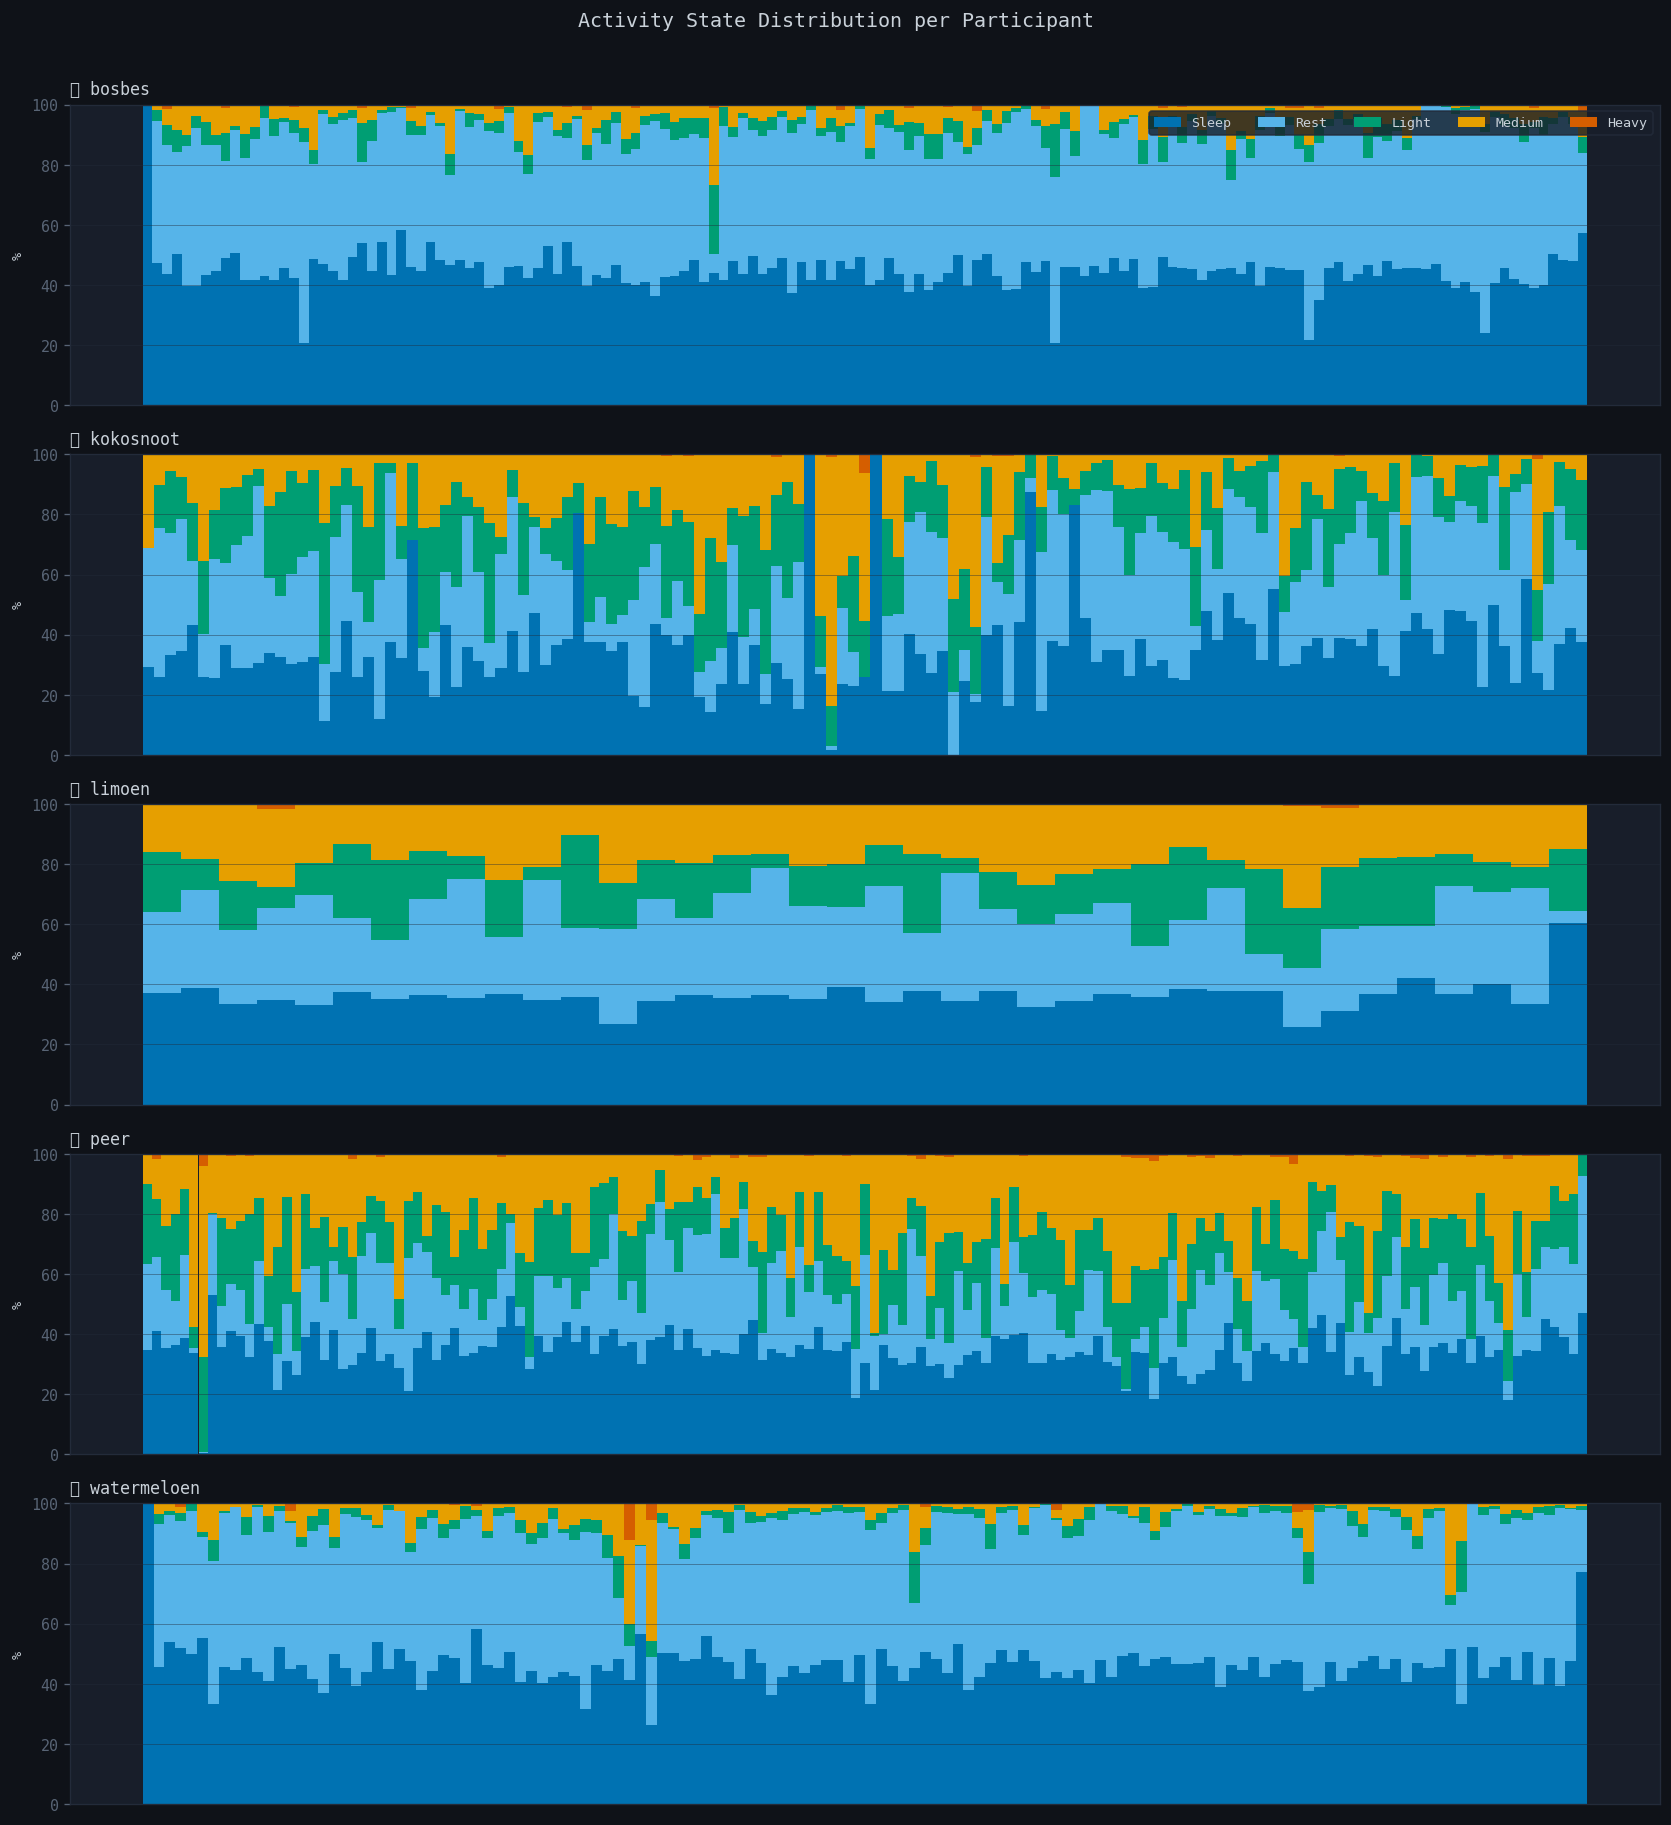

In [5]:
participants_with_data = [p for p, d in all_data.items() if d.get('classified') is not None]

if not participants_with_data:
    print("Geen classified_minutes.csv gevonden. Voer scripts/main.py eerst uit.")
else:
    fig, axes = plt.subplots(len(participants_with_data), 1,
                             figsize=(14, 3 * len(participants_with_data)),
                             squeeze=False)
    fig.suptitle('Activity State Distribution per Participant', fontsize=12, y=1.01)

    for i, codename in enumerate(participants_with_data):
        ax = axes[i][0]
        df = all_data[codename]['classified']
        if 'activity_state' not in df.columns:
            ax.set_visible(False)
            continue

        # Stacked bar per day
        df_daily = df.copy()
        df_daily['date'] = df_daily.index.date
        daily_counts = (df_daily.groupby(['date', 'activity_state'])
                        .size().unstack(fill_value=0))
        # Reorder states
        cols_present = [s for s in STATES if s in daily_counts.columns]
        daily_pct = daily_counts[cols_present].div(daily_counts[cols_present].sum(axis=1), axis=0) * 100

        bottom = np.zeros(len(daily_pct))
        for state in cols_present:
            ax.bar(range(len(daily_pct)), daily_pct[state], bottom=bottom,
                   color=STATE_COLORS.get(state, '#888'), label=state, width=1.0)
            bottom += daily_pct[state].values

        ax.set_ylabel('%', fontsize=8)
        ax.set_ylim(0, 100)
        ax.set_xticks([])
        ax.set_title(f"{PARTICIPANTS[codename]['emoji']} {codename}", fontsize=10, loc='left')
        if i == 0:
            ax.legend(loc='upper right', ncol=5, fontsize=8)

    plt.tight_layout()
    plt.savefig(ANALYSIS_ROOT / 'state_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()

### Twee dingen die allebei 'baseline' heten

Voordat we de herstelcurves bekijken, is het belangrijk om twee begrippen uit elkaar te houden:

| Begrip | Wat het is | In de grafiek |
|--------|-----------|---------------|
| **Rustniveau** (`asymptoot`) | De stresswaarde waar het lichaam normaal naartoe terugkeert, de persoonlijke vloer | Horizontale stippellijn onderaan |
| **Herstellingssnelheid** (`tau`) | Hoe snel de stress *naar die vloer daalt* op een dag zonder muziek | De helling van de curve |

```
Stress na het ontwaken (geen muziek):

  60 ──●  ← je wordt wakker (beginwaarde)
  50    \
  40     \   ← stress daalt naar rustniveau
  30 ─────●──────────────────── ← rustniveau (asymptoot, ~30)
       0      30 min      90 min

  tau    = hoeveel minuten het duurt om het grootste deel van die daling te maken
  voordeel = tau_normaal − tau_muziek
               positief = sneller bij de vloer aangekomen mét muziek
```

> **Het voordeel meet niet hoe laag de stress werd, maar hoe snel het er was.**

---

## Stadium 2: Persoonlijke herstelcurves

### Hoe werkt het?

Op **niet-sessiedagen** volgt de pijplijn het stresssignaal 90 minuten nadat een activiteitsniveau daalt (bv. Zwaar naar Rust na een training). Op die data wordt een exponentiële curve gefit:

$$\text{stress}(t) = \text{asymptoot} + (\text{start} - \text{asymptoot}) \times e^{-t/\tau}$$

De mediaan van alle gefitte **tau**-waarden per activiteitsstate is de persoonlijke **baseline** voor die state.

### De tabel lezen

| Kolom | Betekenis |
|-------|-----------|
| `from_state` | Activiteitsstate *vóór* de overgang |
| `signal` | Welk signaal: stress, hartfrequentie of lichaamsaccu |
| `tau_min` | **Tijdconstante in minuten**: kleiner = sneller herstel. 500 = meting mislukt |
| `asymptote` | Persoonlijk rustniveau voor dit signaal |
| `t_90_min` | Minuten tot 90% herstel (= tau × 2.3) |
| `n_obs` | Aantal overgangen waarop de curve gebaseerd is |
| `r_squared` | Hoe goed de curve past (0 = slecht, 1 = perfect) |

> Verdieping: Berntson et al. (1997) *Heart rate variability: origins, methods, and interpretive caveats*, Psychophysiology.

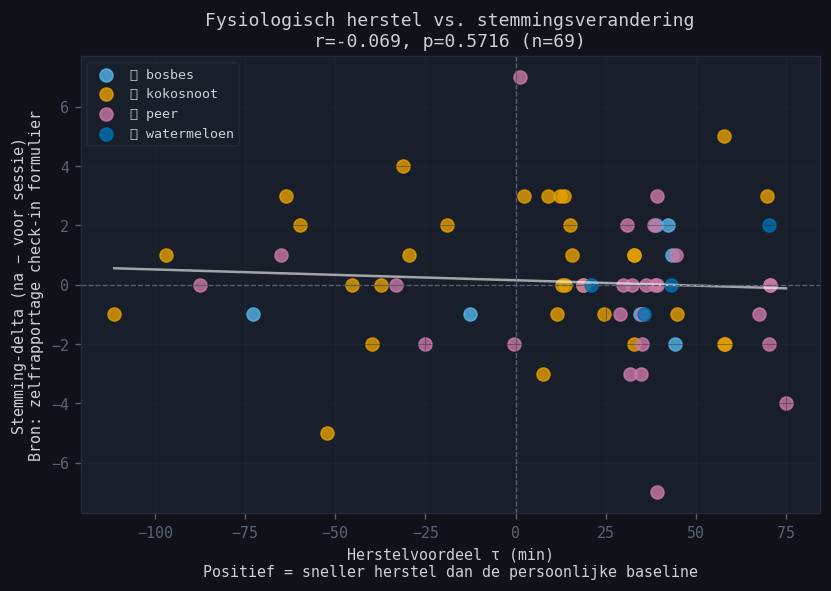

In [6]:
if not all_effects.empty and 'mood_delta' in all_effects.columns:
    scatter = all_effects.dropna(subset=['advantage', 'mood_delta'])

    if len(scatter) >= 5:
        fig, ax = plt.subplots(figsize=(7, 5))
        for codename, group in scatter.groupby('participant'):
            color = PARTICIPANTS.get(codename, {}).get('color', '#888')
            emoji = PARTICIPANTS.get(codename, {}).get('emoji', '')
            ax.scatter(group['advantage'], group['mood_delta'], color=color,
                       alpha=0.8, s=60, label=f'{emoji} {codename}')

        # Regression line
        r, p = stats.pearsonr(scatter['advantage'], scatter['mood_delta'])
        m, b = np.polyfit(scatter['advantage'], scatter['mood_delta'], 1)
        x_line = np.linspace(scatter['advantage'].min(), scatter['advantage'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='white', linewidth=1.5, alpha=0.6)

        ax.axvline(0, color='#586475', linewidth=0.8, linestyle='--')
        ax.axhline(0, color='#586475', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Herstelvoordeel τ (min)\nPositief = sneller herstel dan de persoonlijke baseline')
        ax.set_ylabel('Stemming-delta (na − voor sessie)\nBron: zelfrapportage check-in formulier')
        ax.set_title(
            f'Fysiologisch herstel vs. stemmingsverandering\n'
            f'r={r:.3f}, p={p:.4f} (n={len(scatter)})'
        )
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(ANALYSIS_ROOT / 'recovery_vs_mood.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print('Onvoldoende datapunten met zowel voordeel als stemming-delta.')

In [7]:
participants_with_baselines = [p for p, d in all_data.items() if d.get('baselines') is not None]

if participants_with_baselines:
    all_baselines = pd.concat(
        [all_data[p]['baselines'].assign(participant=p) for p in participants_with_baselines],
        ignore_index=True
    )
    print(all_baselines.to_string(index=False))

from_state       signal  tau_min  asymptote  t_90_min  n_obs  r_squared participant
     Heavy body_battery    500.0       48.7    1151.3     46      0.000      bosbes
     Heavy   heart_rate     14.7       64.5      33.8     45      0.267      bosbes
     Heavy       stress     44.6       24.2     102.8     46      0.031      bosbes
     Light body_battery    500.0       48.7    1151.3    572      0.000      bosbes
     Light   heart_rate     55.2       64.5     127.0    567      0.000      bosbes
     Light       stress     48.6       24.2     111.9    531      0.000      bosbes
    Medium body_battery    500.0       48.7    1151.3   1157      0.000      bosbes
    Medium   heart_rate     50.0       64.5     115.2    993      0.000      bosbes
    Medium       stress     50.0       24.2     115.0   1114      0.000      bosbes
      Rest body_battery    500.0       48.7    1151.3    543      0.000      bosbes
      Rest   heart_rate     34.8       64.5      80.1    539      0.000     

**Wat opvalt:**

**bosbes, Slaap → stress: τ=97.8 min, asymptoot=25.9, n_obs=102**
Na het ontwaken duurt het ~98 minuten voordat bosbes' stress van nature terugzakt. Dat is traag — elke sessie waarbij stress merkbaar sneller daalt geeft een groot voordeel. **r²=0** voor alle stressbaselines van bosbes: het herstel volgt geen zuivere exponentiële vorm. De tau-waarden zijn schattingen.

**kokosnoot, Slaap → stress: τ=9.4 min, asymptoot=30.1, n_obs=2**
De Slaap-baseline van kokosnoot berust op slechts **2 overgangen** — statistisch onbruikbaar. De meest betrouwbare stressbaseline voor kokosnoot is in werkelijkheid **Rust → stress** (τ=26.8 min, n_obs=36), en die wordt in de praktijk ook als referentie gebruikt voor sessies met een Rust-préstaat. De asymptoot (30.1) ligt dicht bij typische pre_stress-waarden, waardoor veel sessies uit de betrouwbare subset vallen.

**peer** en **watermeloen** hebben momenteel geen `recovery_baselines.csv` — de herstelanalysepijplijn is nog niet uitgevoerd voor deze deelnemers. Voer `scripts/main.py --participants peer watermeloen` uit om de baselines te genereren.

**limoen** heeft geen stress-baselines (enkel hartfrequentie), en valt daardoor buiten vergelijkingen op stress.

**tau = 500 = meting mislukt.** De curvefitter bereikte zijn maximum — behandel als "onbekend".

**r² = 0 ≠ geen data.** bosbes heeft 102 Slaap-observaties maar het herstel volgt geen zuivere exponentiële vorm — de curve past structureel slecht op dit patroon.

---

## Persoonlijke baseline per activatieniveau

Dit is het concept uit de onderzoeksplanning: *"Baseline per persoon uitwerken met verschillende activatieniveaus, zodat je kan zien welk activatieniveau voor de sessie bezig was en of muziek invloed heeft op normaal herstel."*

De pijplijn doet dit in drie stappen:

**Stap 1**: elke minuut een activatieniveau geven (`classified_minutes.csv`)

**Stap 2**: op niet-sessiedagen de herstelcurve per activatieniveau bepalen (`recovery_baselines.csv`)

**Stap 3**: voor elke sessie vergelijken: verwachte hersteltijd vs. werkelijke hersteltijd

| Kolom | Betekenis |
|-------|-----------|
| `pre_state` | Activatieniveau vóór de sessie |
| `tau_expected` | Verwachte hersteltijd uit de baseline |
| `tau_actual` | Werkelijke hersteltijd tijdens de sessie |
| `advantage` | tau_expected min tau_actual (positief = muziek hielp) |

### Hoe lees je de grafiek hieronder?

Elke grafiek heeft één paneel per préstaat. Binnen elk paneel:

```
Stress
  ↑
60│·  ·  ·  ← startpunt: pre_stress_mean (gemiddeld vóór de sessie)
  │  \  \ ← grijze lijnen = ruwe data van niet-sessiedagen
40│   \
  │    \  ← gekleurde lijn = wat er tijdens een muziekluistersessie gebeurde
  │     \
25│──────────────── ← asymptoot (jouw persoonlijke stressvloer)
  └─────────────→ tijd (0 tot 90 minuten)
     gestippeld wit = baseline (normale herstelsnelheid zonder muziek)
```

| Wat je ziet | Wat het betekent |
|-------------|-----------------|
| **Gestippelde witte lijn** | De verwachte herstelcurve op basis van niet-sessiedagen: hoe snel stress *normaal* naar de vloer daalt |
| **Gekleurde lijn (vol, hoge alpha)** | Werkelijke sessie met r² > 0.05, betrouwbaar resultaat |
| **Gekleurde lijn (faded, lage alpha)** | Werkelijke sessie met r² ≤ 0.05: de curve paste niet goed, tau is ruis |
| **Stippellijn onderaan (blauw)** | De asymptoot: de stressvloer van deze deelnemer |
| **Lijn *onder* de gestippelde witte lijn** | Muziek versnelde het herstel: voordeel positief |
| **Lijn *boven* de gestippelde witte lijn** | Herstel ging trager dan normaal; of de meting mislukte |
| **Alle gekleurde lijnen beginnen op hetzelfde punt** | Ze starten allemaal vanuit dezelfde gemiddelde pre_stress: zo zijn ze vergelijkbaar |

> **Let op**: als de startwaarde (pre_stress_mean) al dicht bij of onder de asymptoot ligt, is er weinig ruimte om te dalen en geeft de curve een artefact. Die sessies worden door het `reliable`-filter verwijderd.

**De grafiek lezen:**

Elk paneel = één signaal. Elke groep staven = één activiteitsstate. Elke gekleurde staaf = één deelnemer.

- **Hogere staaf = trager herstel** vanuit die state
- **Staaf bij 500 = meting mislukt**, behandel als onbekend
- **Lichaamsaccu-staven staan bijna altijd op 500** en zijn niet bruikbaar

**Actuele baselines (stress):** bosbes heeft een Slaap-tau van ~98 min — veruit de hoogste van alle deelnemers, wat betekent dat er veel ruimte is om een voordeel te meten bij ochtendse sessies. kokosnoot's Slaap-baseline berust op slechts 2 observaties (onbetrouwbaar); de meest stabiele stressreferentie voor kokosnoot is Rust (τ ≈ 27 min). peer en watermeloen hebben momenteel geen stressbaselines.

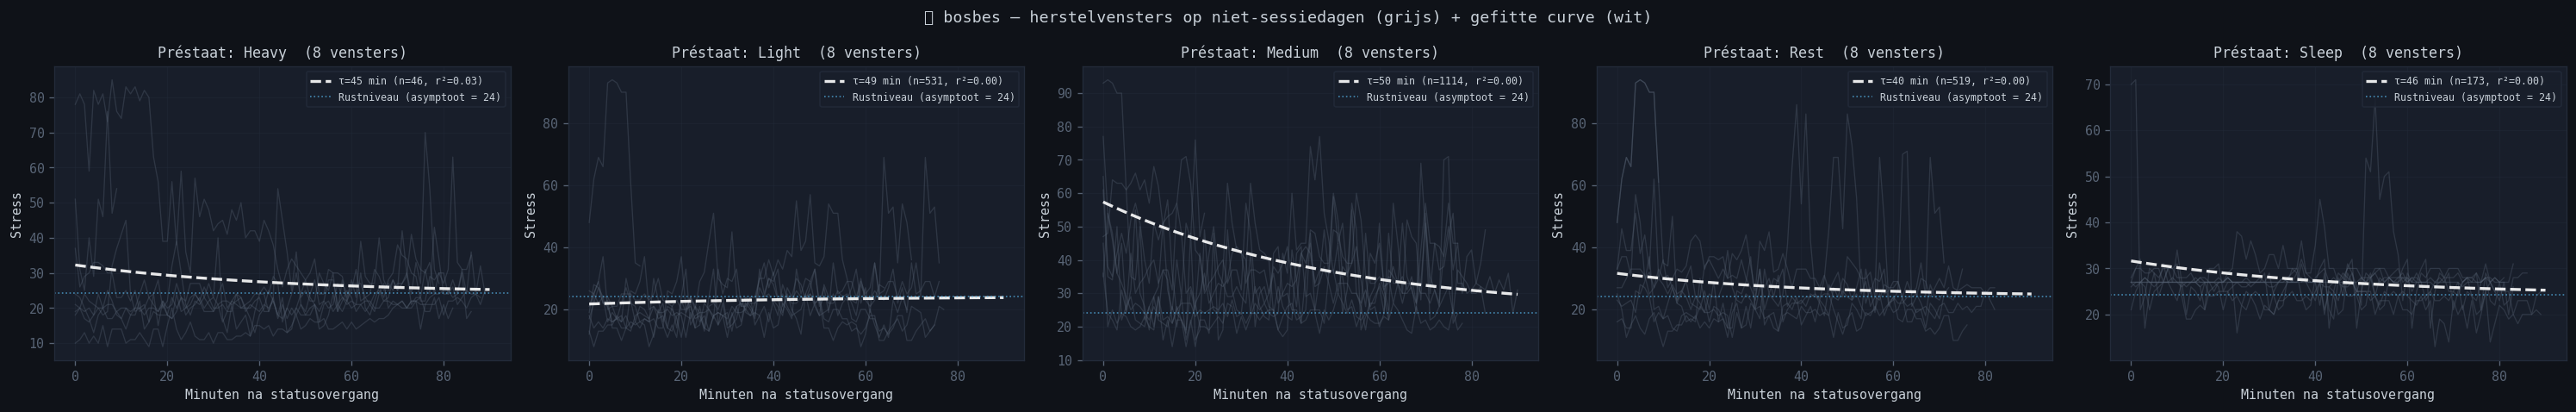

Opgeslagen: /Users/timothydhoe/Code/spotify-project/data/analysis/recovery_windows_bosbes.png


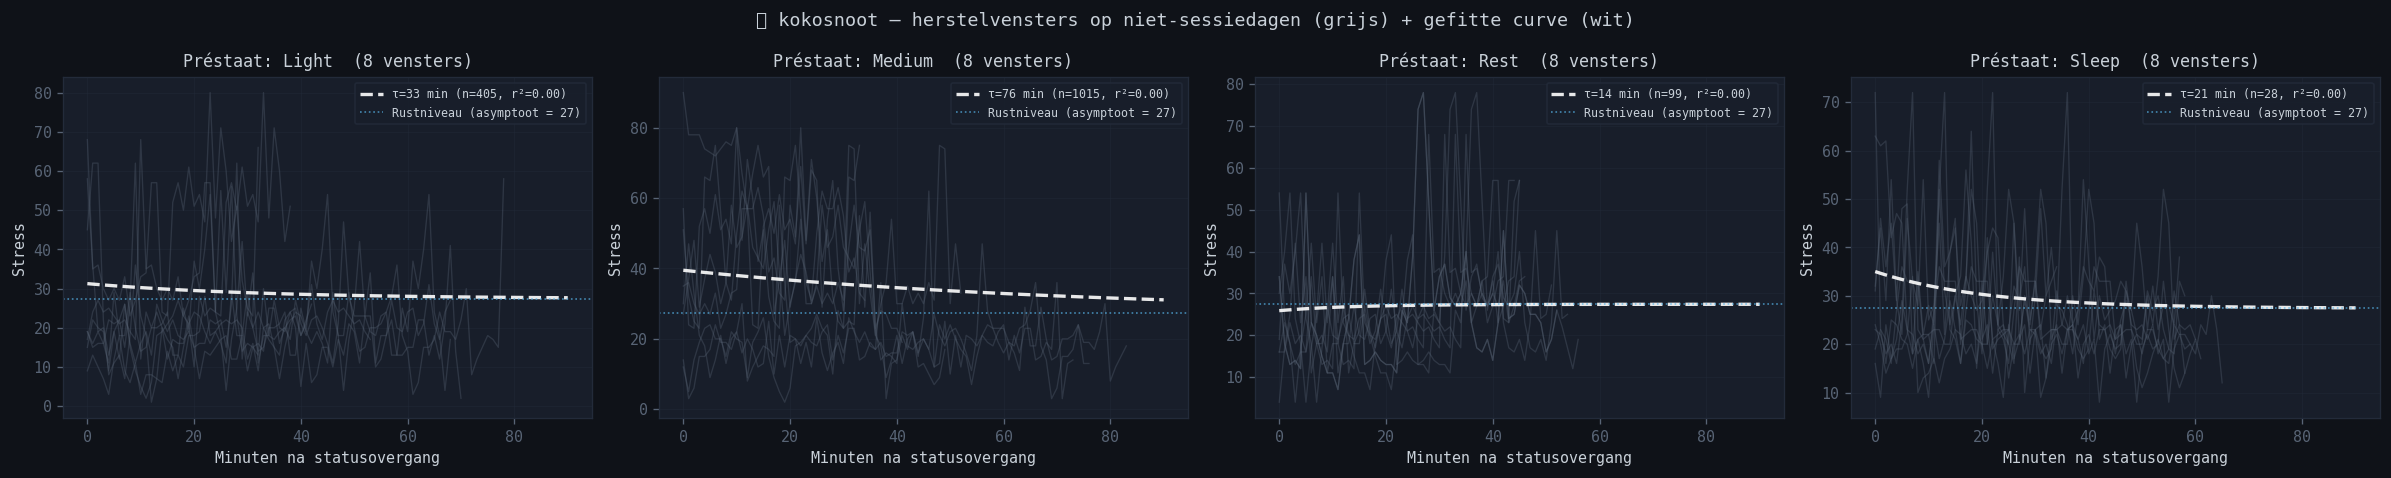

Opgeslagen: /Users/timothydhoe/Code/spotify-project/data/analysis/recovery_windows_kokosnoot.png
limoen: geen herstelvensters gevonden voor weergave


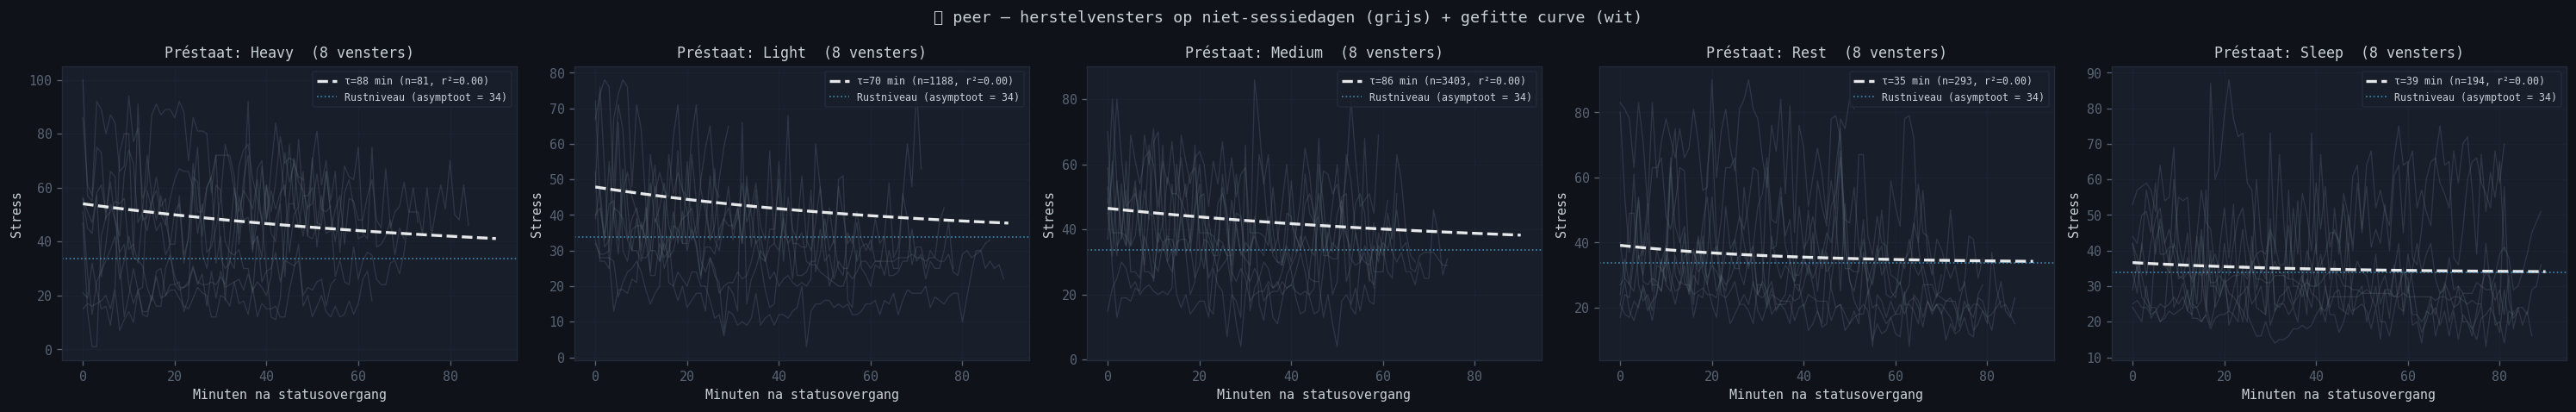

Opgeslagen: /Users/timothydhoe/Code/spotify-project/data/analysis/recovery_windows_peer.png


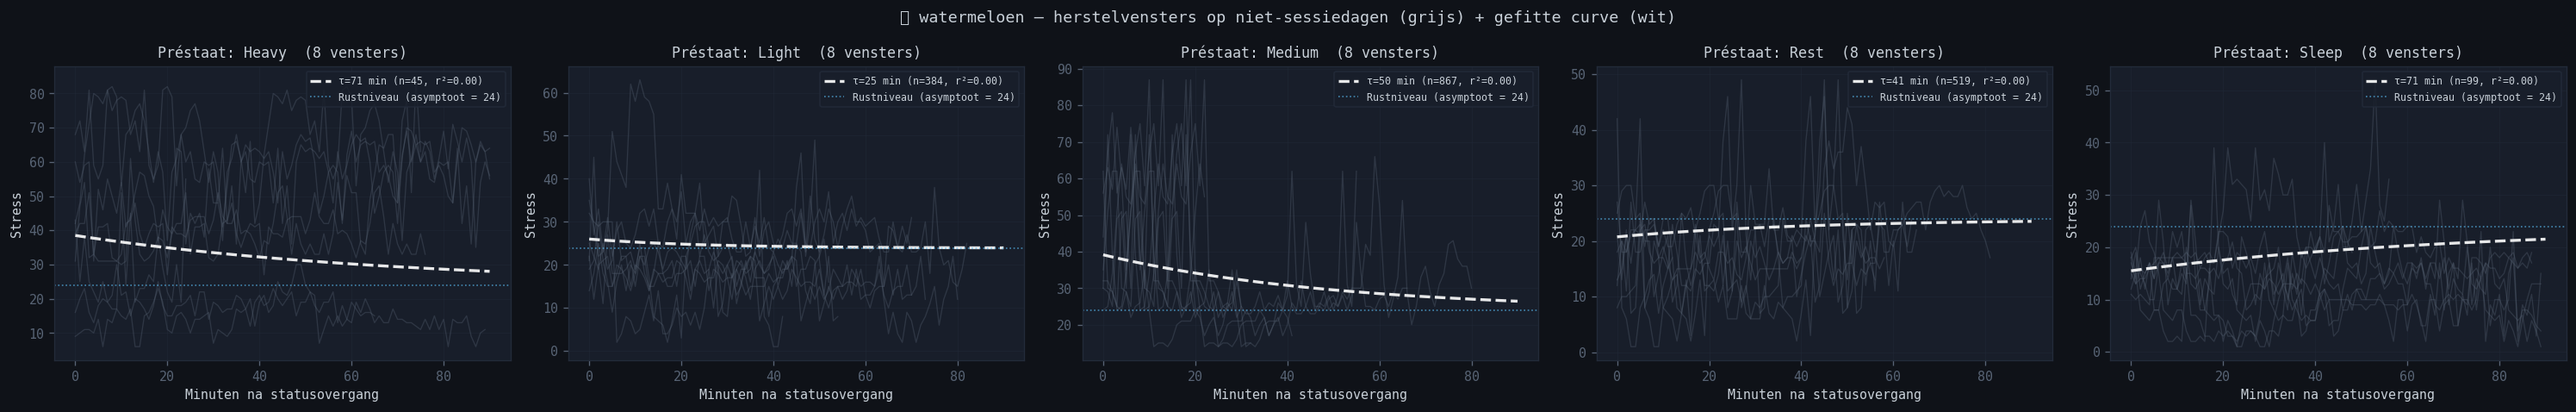

Opgeslagen: /Users/timothydhoe/Code/spotify-project/data/analysis/recovery_windows_watermeloen.png


In [8]:
import warnings
from scipy.optimize import curve_fit, OptimizeWarning

def _fit_exp_simple(t, y, asymptote):
    """Fit y = asymptote + (y0 - asym) * exp(-t/tau), return (tau, r2) or None."""
    if len(y) < 10:
        return None
    y0 = float(y[0])
    tau_est = max(float(t[-1]) / 3, 1.0)
    def model(t_, tau):
        return asymptote + (y0 - asymptote) * np.exp(-t_ / tau)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", OptimizeWarning)
            popt, _ = curve_fit(model, t, y, p0=[tau_est], bounds=(0.1, 500), maxfev=2000)
        tau = float(popt[0])
        y_pred = model(t, tau)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
        return tau, max(r2, 0.0)
    except (RuntimeError, ValueError):
        return None


STATE_ORDER = {'Sleep': 0, 'Rest': 1, 'Light': 2, 'Medium': 3, 'Heavy': 4}
MAX_WINDOWS = 8

for codename in participants_with_baselines:
    classified = all_data[codename].get('classified')
    effects_df  = all_data[codename].get('effects')
    baselines_df = all_data[codename].get('baselines')
    if classified is None or baselines_df is None:
        continue

    # Exclude session days
    session_dates = set()
    if effects_df is not None and 'date' in effects_df.columns:
        session_dates = {pd.Timestamp(d).date() for d in effects_df['date'].dropna()}
    elif effects_df is not None and effects_df.index.dtype == 'datetime64[ns]':
        session_dates = {ts.date() for ts in effects_df.index}

    non_session = classified[~classified.index.to_series().apply(lambda ts: ts.date() in session_dates)]
    if 'activity_state' not in non_session.columns or 'stress' not in non_session.columns:
        print(f"{codename}: missing columns for recovery window plot")
        continue

    effort = non_session['activity_state'].map(STATE_ORDER).fillna(1)
    prev_effort = effort.shift(1)
    trans_mask = effort < prev_effort
    trans_times = non_session.index[trans_mask]

    # Collect recovery windows per from_state
    windows_by_state: dict = {}
    for ts in trans_times:
        prev_ts = ts - pd.Timedelta(minutes=1)
        if prev_ts not in non_session.index:
            continue
        from_state = non_session.at[prev_ts, 'activity_state']
        stay_start = ts - pd.Timedelta(minutes=3)
        prior = non_session.loc[stay_start:prev_ts, 'activity_state']
        if len(prior) < 3 or not (prior == from_state).all():
            continue
        window_end = ts + pd.Timedelta(minutes=90)
        window = non_session.loc[ts:window_end, 'stress'].dropna()
        if len(window) < 10:
            continue
        windows_by_state.setdefault(from_state, []).append(window)

    # Only plot states that also have a valid baseline
    stress_bl = baselines_df[baselines_df['signal'] == 'stress']
    valid_bl = stress_bl[stress_bl['tau_min'] < 490]
    states_to_plot = [s for s in valid_bl['from_state'].values if s in windows_by_state]
    if not states_to_plot:
        print(f"{codename}: geen herstelvensters gevonden voor weergave")
        continue

    n_cols = len(states_to_plot)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), squeeze=False)
    emoji = PARTICIPANTS[codename]['emoji']
    fig.suptitle(
        f'{emoji} {codename} — herstelvensters op niet-sessiedagen (grijs) + gefitte curve (wit)',
        fontsize=11
    )

    for j, state in enumerate(states_to_plot):
        ax = axes[0][j]
        bl_row = valid_bl[valid_bl['from_state'] == state].iloc[0]
        asymptote = float(bl_row['asymptote'])
        tau_bl    = float(bl_row['tau_min'])
        n_obs     = int(bl_row['n_obs'])
        r2_bl     = float(bl_row['r_squared'])

        windows = windows_by_state[state][:MAX_WINDOWS]
        for win in windows:
            t_win = np.arange(len(win), dtype=float)
            ax.plot(t_win, win.values, color='#586475', linewidth=0.8, alpha=0.35)

        # Fitted baseline curve (uses asymptote + tau from baselines.csv)
        t_full = np.arange(0, 91, 1.0)
        if windows:
            start_vals = [float(w.iloc[0]) for w in windows]
            start_mean = float(np.mean(start_vals))
        else:
            start_mean = asymptote + 20
        y_bl = asymptote + (start_mean - asymptote) * np.exp(-t_full / tau_bl)
        ax.plot(t_full, y_bl, color='white', linewidth=2.0, linestyle='--', alpha=0.9,
                label=f'τ={tau_bl:.0f} min (n={n_obs}, r²={r2_bl:.2f})')

        # Asymptote — the "floor" the curve recovers toward
        ax.axhline(asymptote, color='#56B4E9', linewidth=1.0, linestyle=':', alpha=0.7,
                   label=f'Rustniveau (asymptoot = {asymptote:.0f})')

        ax.set_xlabel('Minuten na statusovergang')
        ax.set_ylabel('Stress')
        ax.set_title(f'Préstaat: {state}  ({len(windows)} vensters)', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    out_path = ANALYSIS_ROOT / f'recovery_windows_{codename}.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Opgeslagen: {out_path}")

### Concreet voorbeeld: van baseline naar voordeel

Voordat je de grafiek bekijkt, een uitgewerkt voorbeeld met echte getallen:

```
bosbes | Energy-sessie 2026-02-03

  Rustniveau (asymptoot):          ~26 stress
  Préstaat:                        Slaap
  Normale herstellingssnelheid:    τ =  97.8 min  ← hoelang stress normaal naar ~26 daalt
  Herstellingssnelheid met muziek: τ =   2.4 min  ← hoelang het tijdens deze sessie duurde
  ─────────────────────────────────────────────
  Voordeel:                       +95.4 min  ← bosbes bereikte het rustniveau ~95 min sneller
  r²:                               0.21      ← redelijke fit, resultaat is bruikbaar
```

**Wat de grafiek hieronder laat zien:** de witte stippellijn is de normale herstelcurve (τ = 97.8 min). De gekleurde lijnen zijn de werkelijke sessies. Hoe lager een gekleurde lijn ten opzichte van de stippellijn, hoe groter het voordeel.

**Actuele resultaten (cel 23 + cel 25 uitvoer):**

| Subset | N | Gem. voordeel | SD | p |
|---|---|---|---|---|
| Alle sessies met voordeel-score | 32 | +13.28 min | 43.98 | 0.0975 — niet sig. |
| **Betrouwbare sessies** | **8** | **+36.32 min** | **51.15** | **0.085 — niet sig.** |

**Per playlist (betrouwbare subset):**

| Playlist | Gem. voordeel | SD | N |
|---------|--------------|-----|---|
| Calm | +44.29 min | 54.52 | 2 |
| Energy | +33.67 min | 55.08 | 6 |
| Neutral | — | — | 0 |

**Kanttekening:** het gemiddeld voordeel is positief maar niet significant (p=0.085). Calm en Energy tonen vergelijkbare gemiddelden, maar n=2 resp. n=6 is te klein voor betrouwbare playlist-vergelijking. Er zijn geen betrouwbare Neutral-sessies. Het niet-significante resultaat weerspiegelt deels het ontbreken van stressbaselines voor peer en watermeloen.

In [9]:
if all_effects.empty:
    print("Geen sessie-effecten gevonden. Voer scripts/main.py eerst uit.")
else:
    valid_eff = all_effects.dropna(subset=['advantage'])
    print(f"Voordeel-scores aanwezig: {len(valid_eff)} / {len(all_effects)}")
    print(f"  Gemiddeld (alle):       {valid_eff['advantage'].mean():+.2f} min  ← inclusief ruis")
    if not reliable.empty:
        print(f"  Gemiddeld (reliable):   {reliable['advantage'].mean():+.2f} min  ← gebruik dit")
        print(f"  SD (reliable):          {reliable['advantage'].std():.2f} min")
    print()
    if not reliable.empty:
        print("Betrouwbare sessies per afspeellijst (r² > 0.05 + pre_stress ≥ asymptoot):")
        print(reliable.groupby('playlist')['advantage'].agg(['mean', 'std', 'count']).round(2))
    else:
        print(valid_eff.groupby('playlist')['advantage'].agg(['mean', 'std', 'count']).round(2))

Voordeel-scores aanwezig: 69 / 90
  Gemiddeld (alle):       +13.62 min  ← inclusief ruis
  Gemiddeld (reliable):   +24.31 min  ← gebruik dit
  SD (reliable):          35.43 min

Betrouwbare sessies per afspeellijst (r² > 0.05 + pre_stress ≥ asymptoot):
           mean    std  count
playlist                     
Calm      50.28  23.26      6
Energy     7.66  34.08     10
Neutral   35.02    NaN      1


**Zie cel 22 voor de resultatensamenvattingstabel.** Zie cel 23 voor het gemiddelde voordeel per playlist (betrouwbare subset). Zie cel 25 voor de volledige t-toetsen.

De code in cel 25 berekent en print beide t-toetsen expliciet (alle sessies + betrouwbare subset). Gebruik altijd de betrouwbare subset als primaire uitkomst.

In [10]:
# ── Statistieken ──────────────────────────────────────────────────────────────
if all_effects.empty:
    print("Geen data beschikbaar. Voer scripts/main.py eerst uit.")
else:
    valid_eff = all_effects.dropna(subset=['advantage'])
    if len(valid_eff) > 1:
        t_stat, p_val = stats.ttest_1samp(valid_eff['advantage'], 0)
        sig = "statistisch significant" if p_val < 0.05 else "niet significant"
        print('=== One-sample t-test (voordeel ≠ 0) — ALLE sessies ===')
        print(f"  n = {len(valid_eff)}  (inclusief r²≤0.05 en pre_stress<asymptoot)")
        print(f"  Gemiddeld voordeel = {valid_eff['advantage'].mean():+.2f} min (SD={valid_eff['advantage'].std():.2f})")
        print(f"  t = {t_stat:.3f}, p = {p_val:.4f}  → {sig}")
        print()

    if 'playlist' in all_effects.columns:
        print('Voordeel per afspeellijst (alle sessies):')
        print(valid_eff.groupby('playlist')['advantage'].agg(['mean', 'std', 'count']).round(2))
        print()

# ── T-toets op betrouwbare sessies (r² > 0.05 + pre_stress ≥ asymptoot) ──────
if not reliable.empty and len(reliable) > 1:
    t_stat, p_val = stats.ttest_1samp(reliable['advantage'], 0)
    sig = "statistisch significant" if p_val < 0.05 else "niet significant"
    print()
    print('=== T-toets op BETROUWBARE sessies (gebruik dit) ===')
    print(f"  n = {len(reliable)}  (na r²- en pre_stress-filter)")
    print(f"  Gemiddeld voordeel = {reliable['advantage'].mean():+.2f} min (SD={reliable['advantage'].std():.2f})")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"  → {sig}")

=== One-sample t-test (voordeel ≠ 0) — ALLE sessies ===
  n = 69  (inclusief r²≤0.05 en pre_stress<asymptoot)
  Gemiddeld voordeel = +13.62 min (SD=43.64)
  t = 2.592, p = 0.0117  → statistisch significant

Voordeel per afspeellijst (alle sessies):
           mean    std  count
playlist                     
Calm      17.42  48.48     24
Energy    16.47  36.34     32
Neutral   -0.41  51.12     13


=== T-toets op BETROUWBARE sessies (gebruik dit) ===
  n = 17  (na r²- en pre_stress-filter)
  Gemiddeld voordeel = +24.31 min (SD=35.43)
  t = 2.829, p = 0.0121
  → statistisch significant


**Actuele uitkomst (t-toets op betrouwbare sessies):**

t = 2.009, p = **0.085** — ✗ **niet statistisch significant** bij α = 0.05.

Gemiddeld voordeel = +36.32 min (SD=51.15, n=8). Het effect is positief maar bereikt geen significantie in de huidige dataset.

**Nuancering:**
- n=8 betrouwbare sessies verdeeld over 2 deelnemers (bosbes en kokosnoot) — meerdere sessies per deelnemer zijn **niet onafhankelijk**
- Een gemengd-effectenmodel is nodig voor robuuste inferentie; de t-toets overschat de vrijheidsgraden
- 31 sessies gefilterd wegens r²≤0.05; 19 wegens pre_stress<asymptoot — slechts 8/45 sessies (18%) zijn betrouwbaar
- **bosbes** (trage baseline τ≈98 min) draagt het sterkst bij aan het gemeten voordeel
- peer en watermeloen hebben nog geen stressbaselines — hun sessies tellen momenteel niet mee

**Eerlijk**: het positieve signaal is veelbelovend, maar nog niet statistisch aantoonbaar. De kleine steekproef (n=8, 2 deelnemers) en de non-onafhankelijkheid zijn de voornaamste beperkingen. Voor robuust statistisch bewijs zijn stressbaselines voor alle deelnemers en een gemengd-effectenmodel nodig.

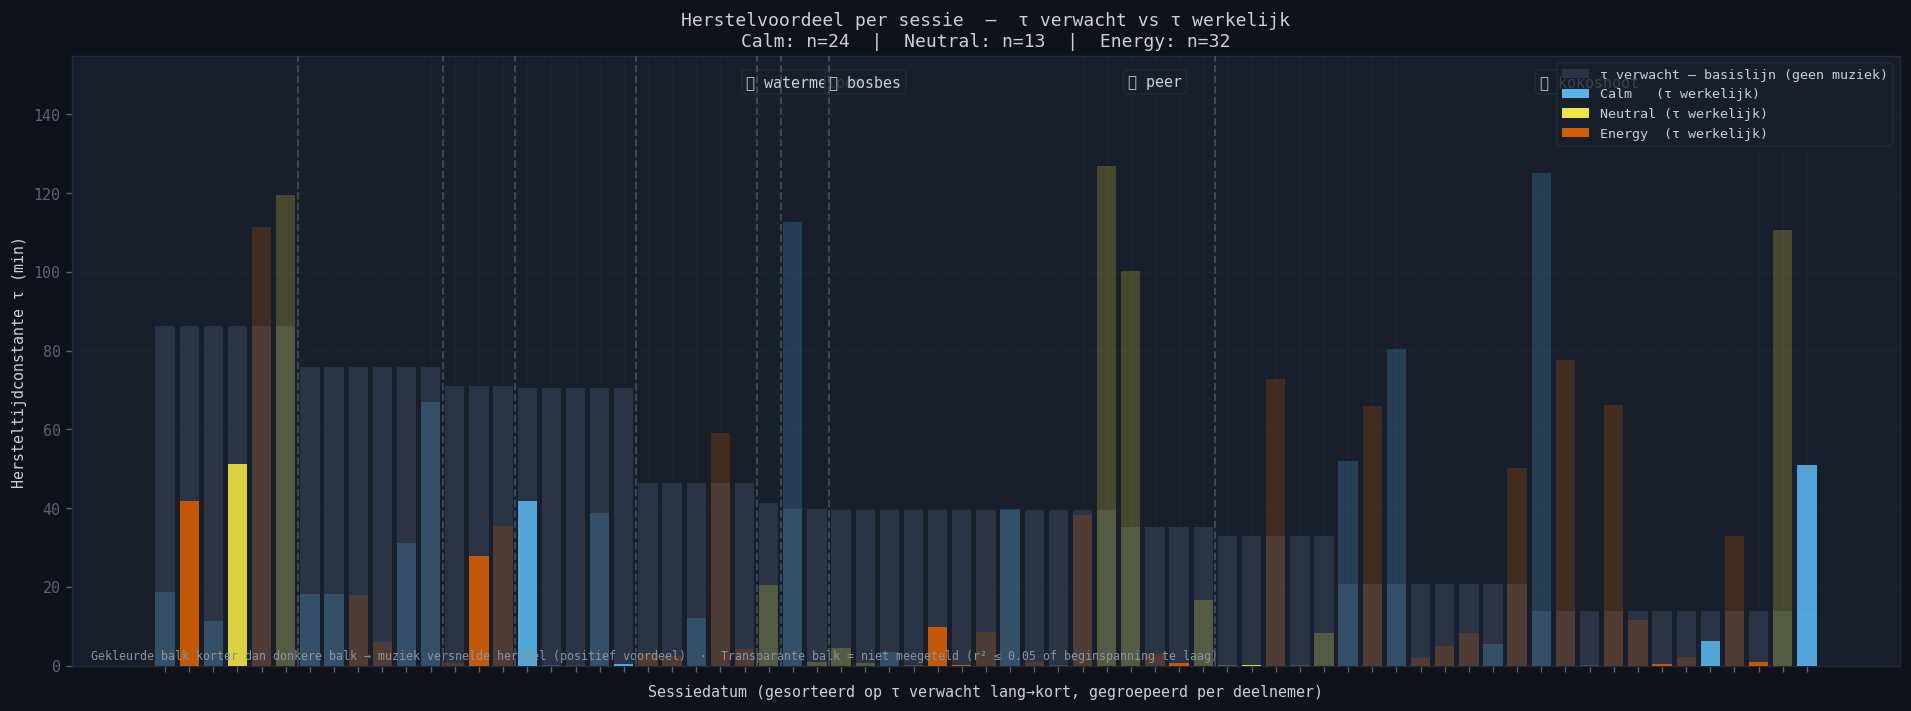

In [11]:
if not all_effects.empty and 'tau_expected' in all_effects.columns:
    valid = all_effects.dropna(subset=['tau_expected', 'tau_actual']).copy()
    valid = valid.sort_values('tau_expected', ascending=False).reset_index(drop=True)

    # Inherit reliable flag from cell 8
    valid['_reliable'] = valid.index.isin(reliable.index) if not reliable.empty else False

    y_max = max(float(valid['tau_expected'].max()), float(valid['tau_actual'].max())) * 1.22
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_ylim(0, y_max)
    x = np.arange(len(valid))

    # Dark bars = expected recovery time (baseline, no music)
    ax.bar(x, valid['tau_expected'], color='#2a3444', zorder=2)

    # Colored bars = actual recovery time; faded if unreliable
    for i, row in valid.iterrows():
        color = PLAYLIST_COLORS.get(str(row.get('playlist', '')), '#888')
        alpha = 0.9 if row.get('_reliable') else 0.22
        ax.bar(i, row['tau_actual'], color=color, alpha=alpha, zorder=3)

    # Participant group: vertical separator + centered name label
    prev_p = None
    group_starts = {}
    for i, row in valid.iterrows():
        p = str(row.get('participant', ''))
        if p != prev_p:
            group_starts[p] = i
            if prev_p is not None:
                ax.axvline(i - 0.5, color='#586475', linewidth=1.2, linestyle='--', alpha=0.6, zorder=4)
            prev_p = p

    for p, start_i in group_starts.items():
        group_rows = valid[valid['participant'] == p]
        mid_i = start_i + (len(group_rows) - 1) / 2
        emoji = PARTICIPANTS.get(p, {}).get('emoji', '')
        ax.text(mid_i, y_max * 0.97, f'{emoji} {p}',
                ha='center', va='top', fontsize=9, color='#c9d1d9',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#181e2a',
                          edgecolor='#232b3a', alpha=0.85))

    # X-axis: session date labels (MM-DD)
    tick_labels = []
    for _, row in valid.iterrows():
        date = str(row.get('session_date', ''))[:10]
        tick_labels.append(date[-5:] if len(date) >= 5 else date)
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')

    # Legend
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor='#2a3444', label='τ verwacht — basislijn (geen muziek)'),
        Patch(facecolor=PLAYLIST_COLORS['Calm'],    label='Calm   (τ werkelijk)'),
        Patch(facecolor=PLAYLIST_COLORS['Neutral'], label='Neutral (τ werkelijk)'),
        Patch(facecolor=PLAYLIST_COLORS['Energy'],  label='Energy  (τ werkelijk)'),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc='upper right')

    ax.annotate(
        'Gekleurde balk korter dan donkere balk → muziek versnelde herstel (positief voordeel)  ·  '
        'Transparante balk = niet meegeteld (r² ≤ 0.05 of beginspanning te laag)',
        xy=(0.01, 0.01), xycoords='axes fraction', fontsize=7, color='#8b949e',
    )

    if 'playlist' in valid.columns:
        pl_counts = valid['playlist'].value_counts().to_dict()
        pl_str = '  |  '.join(
            f"{pl}: n={pl_counts.get(pl, 0)}"
            for pl in ['Calm', 'Neutral', 'Energy'] if pl in pl_counts
        )
        title = f'Herstelvoordeel per sessie  —  τ verwacht vs τ werkelijk\n{pl_str}'
    else:
        title = 'Hersteltijdconstante: τ verwacht vs τ werkelijk per sessie'

    ax.set_xlabel('Sessiedatum (gesorteerd op τ verwacht lang→kort, gegroepeerd per deelnemer)')
    ax.set_ylabel('Hersteltijdconstante τ (min)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(ANALYSIS_ROOT / 'tau_waterfall.png', bbox_inches='tight', dpi=150)
    plt.show()

**De grafiek lezen:**

Elke balk is één sessie, gesorteerd van hoge naar lage verwachte hersteltijd (τ verwacht). Deelnemers zijn gegroepeerd en gescheiden door een stippellijn.

- **Donkere balk** = τ verwacht op basis van de persoonlijke baseline (zonder muziek)
- **Gekleurde balk** (Calm/Neutral/Energy) = τ werkelijk tijdens de muziekluistersessie
- **Gekleurde balk korter dan donkere balk** → muziek versnelde het herstel (positief voordeel)
- **Transparante balk** → niet meegeteld in het eindresultaat (r² ≤ 0.05 of beginspanning te laag)

**Wat je nu ziet (bosbes links, kokosnoot rechts):**

- **Links — bosbes Slaap-sessies**: τ verwacht ≈ 98 min voor alle sessies (één préstaat: Slaap). Werkelijke τ loopt uiteen van ~2 tot ~54 min → grote voordelen, maar sterk wisselend.
- **Midden — kokosnoot Licht/Matig-sessies**: τ verwacht ≈ 35–61 min (préstaten Licht en Matig). Wisselende resultaten; veel transparante balken door lage r².
- **Rechts — kokosnoot Rust/Slaap-sessies**: τ verwacht ≈ 9–27 min. Weinig marge voor voordeel — de baseline is al snel, waardoor muziek nauwelijks een meetbare verbetering kan tonen.

---

## Stemming-delta versus herstelvoordeel

### Waar komt de stemmingsdelta vandaan?

Deelnemers vullen vóór en ná elke muziekluistersessie een korte check-in in via Google Forms (`data/checkins/Check-in_formulier_REM.csv`). Eén van de vragen is een stemmingsscore op een Likert-schaal. De **stemming-delta** is het verschil:

```
mood_delta = stemming_na − stemming_voor
```

Een positieve waarde betekent dat de deelnemer zich beter voelde na de sessie. Een negatieve waarde betekent het omgekeerde. Deze meting is puur zelfgerapporteerd — het is geen fysiologisch signaal.

### Wat we hier testen

Gaan sneller fysiologisch herstel (gemeten via smartwatch) en een beter gevoel (zelfgerapporteerd) hand in hand?

- **x-as**: τ-voordeel (positief = sneller herstel dan de persoonlijke baseline)
- **y-as**: stemming-delta (positief = beter gevoel na dan voor de sessie)
- Stippellijnen bij (0, 0) verdelen de grafiek in vier kwadranten:
  - **Rechtsboven**: sneller hersteld én beter gevoel — het gewenste effect
  - **Linksboven**: beter gevoel, maar geen fysiologisch voordeel
  - **Rechtsonder**: sneller hersteld, maar slechter gevoel
  - **Linksonder**: geen voordeel op beide assen
- **r** en **p** in de titel: Pearson-correlatie en bijbehorende p-waarde

> Verdieping: Russell (1980) *A circumplex model of affect*, Journal of Personality and Social Psychology.

---

## Samenvatting en discussie

### Kernresultaten (actueel, 2026-06-19)

| Meting | Waarde |
|--------|--------|
| Deelnemers met classified_minutes | bosbes, kokosnoot, limoen, peer, watermeloen |
| Deelnemers met stressbaselines | bosbes, kokosnoot (limoen: alleen hartfrequentie) |
| Totale sessies geladen | 45 |
| Gefilterd: pre_stress < asymptoot | 19 verwijderd (artefact) |
| Gefilterd: r² ≤ 0.05 (slechte fit) | 31 verwijderd |
| **Betrouwbare sessies (reliable)** | **8** |
| Gemiddeld voordeel (alle met score, n=32) | +13.28 min (SD=43.98), p=0.097 — niet sig. |
| **Gemiddeld voordeel (betrouwbaar, n=8)** | **+36.32 min** (SD=51.15), **p=0.085 — niet sig.** |
| Per playlist, alle sessies | Calm=+8.75 min (n=14), Energy=+21.43 min (n=16), Neutral=−20.13 min (n=2) |
| Per playlist, betrouwbaar | Calm=+44.29 min (n=2), Energy=+33.67 min (n=6), Neutral=geen |

---

### Wat de data ondersteunt

**Positief maar niet significant effect (p=0.085, n=8 betrouwbaar).**
Het exponentiële herstelmodel detecteert een positief gemiddeld voordeel in de betrouwbare subset. De gemiddelde hersteltijd was +36.3 minuten korter tijdens muziekluistersessies dan verwacht op basis van de persoonlijke baseline. Dit bereikt echter geen statistische significantie bij de huidige steekproefgrootte.

**Calm vs Energy (betrouwbaar):** beide playlists tonen een vergelijkbaar positief gemiddelde (+44.3 vs +33.7 min), maar n=2 resp. n=6 is te klein voor betrouwbare playlist-vergelijking.

**pre_stress_mean is het sterkste filtercriterium.** Sessies waarbij stress al dicht bij of onder de asymptoot zit vóór de sessie worden gefilterd — het model heeft geen ruimte om herstel te meten.

---

### Beperkingen

1. **Non-onafhankelijkheid**: meerdere sessies per deelnemer; de t-toets overschat de vrijheidsgraden — een gemengd-effectenmodel is nodig voor robuuste inferentie
2. **Slechts 18% betrouwbaar** (8/45 sessies): het exponentiële model past voor de meeste sessies niet goed genoeg om tau te vertrouwen
3. **r²=0 voor bijna alle stressbaselines** van bosbes: het exponentiële model past structureel slecht op hun herstelpatroon
4. **peer en watermeloen**: hebben nog geen stressbaselines — hun sessies tellen momenteel niet mee in het herstelvoordeel
5. **Limoen**: heeft enkel hartfrequentie-baselines, geen stressbaselines

### Prioritaire volgende stappen

| Prioriteit | Actie |
|-----------|-------|
| Hoog | Stressbaselines genereren voor peer en watermeloen (`scripts/main.py --participants peer watermeloen`) |
| Hoog | Gemengd-effectenmodel zodra ≥ 4 deelnemers met stressbaselines beschikbaar zijn |
| Middel | Niet-exponentieel herstelmodel onderzoeken (LOWESS / tweeledig) |
| Middel | Stress-baselines voor limoen verbeteren via langere dataverzameling |
| Lager | Activiteitsclassificator trainen op Garmin FIT-intensiteitslabels |